In [65]:
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from IPython.display import display

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

import shap


# SETTINGS
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "Degradation (%)"
KNN_NEIGHBORS = 5

In [66]:
# Configuration
RANDOM_STATE = 42
TARGET_COL = "Degradation (%)"
KNN_NEIGHBORS = 5

In [67]:
df = pd.read_csv("../data/Data.csv")
print(f"Loaded shape: {df.shape}")

df.sample(10, random_state=RANDOM_STATE)

Loaded shape: (374, 8)


,MOF,Surface area (m2/g),Pore Volume (cm3/g),Catalyst dosage (g/L),Antibiotic dosage (mg/L),Illumination time (min),pH,Degradation (%)
329,MIL-100-PANI,950.00,0.300,0.25,10,15,5.00,8.4
33,MIL-101,180.41,0.320,0.15,50,15,8.20,79.0
15,MIL-101,180.41,0.320,0.20,50,0,4.10,25.0
325,MIL-100-PANI,950.00,0.300,0.25,10,105,3.00,35.8
57,MIL-88A,15.95,0.110,0.25,200,70,3.45,96.8
239,AgI-UiO-66-NH2,425.88,0.273,0.30,10,15,4.30,60.0
76,MIL-88A,15.95,0.110,1.00,200,80,3.45,99.5
119,MIL-88A,15.95,0.110,0.25,200,30,7.00,27.1
332,MIL-100-PANI,950.00,0.300,0.25,10,60,5.00,12.7
126,MIL-88A,15.95,0.110,0.25,200,0,9.00,15.5


In [68]:
buffer_info = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
})

buffer_info

,dtype,n_unique,n_missing
MOF,object,10,0
Surface area (m2/g),float64,13,0
Pore Volume (cm3/g),float64,13,0
Catalyst dosage (g/L),float64,12,0
Antibiotic dosage (mg/L),int64,7,0
Illumination time (min),int64,25,0
pH,float64,18,0
Degradation (%),float64,302,0


In [69]:
# Duplicate analysis
n_exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_duplicates}")

if n_exact_duplicates > 0:
    duplicates_df = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())

Exact duplicate rows: 0


UNIVARIATE DESCRIPTIVE STATISTICS


,Min,Max,Mean,Median,Std,Q1,Q3,IQR,Skewness,N Unique,N Obs
Variable,,,,,,,,,,,
Surface area (m2/g),15.95,1548.30,374.222,252.59,351.250,180.410,425.880,245.47,1.177,13,374
Pore Volume (cm3/g),0.11,0.86,0.353,0.30,0.247,0.200,0.320,0.12,1.190,13,374
Catalyst dosage (g/L),0.05,2.00,0.412,0.30,0.409,0.250,0.500,0.25,2.656,12,374
Antibiotic dosage (mg/L),10.00,200.00,66.588,40.00,74.552,10.000,50.000,40.00,1.142,7,374
Illumination time (min),0.00,360.00,43.810,30.00,46.320,10.000,60.000,50.00,2.260,25,374
pH,1.00,12.20,5.871,5.50,2.489,4.100,8.000,3.90,0.078,18,374
Degradation (%),1.30,100.00,52.444,54.05,29.177,27.225,75.875,48.65,-0.051,302,374


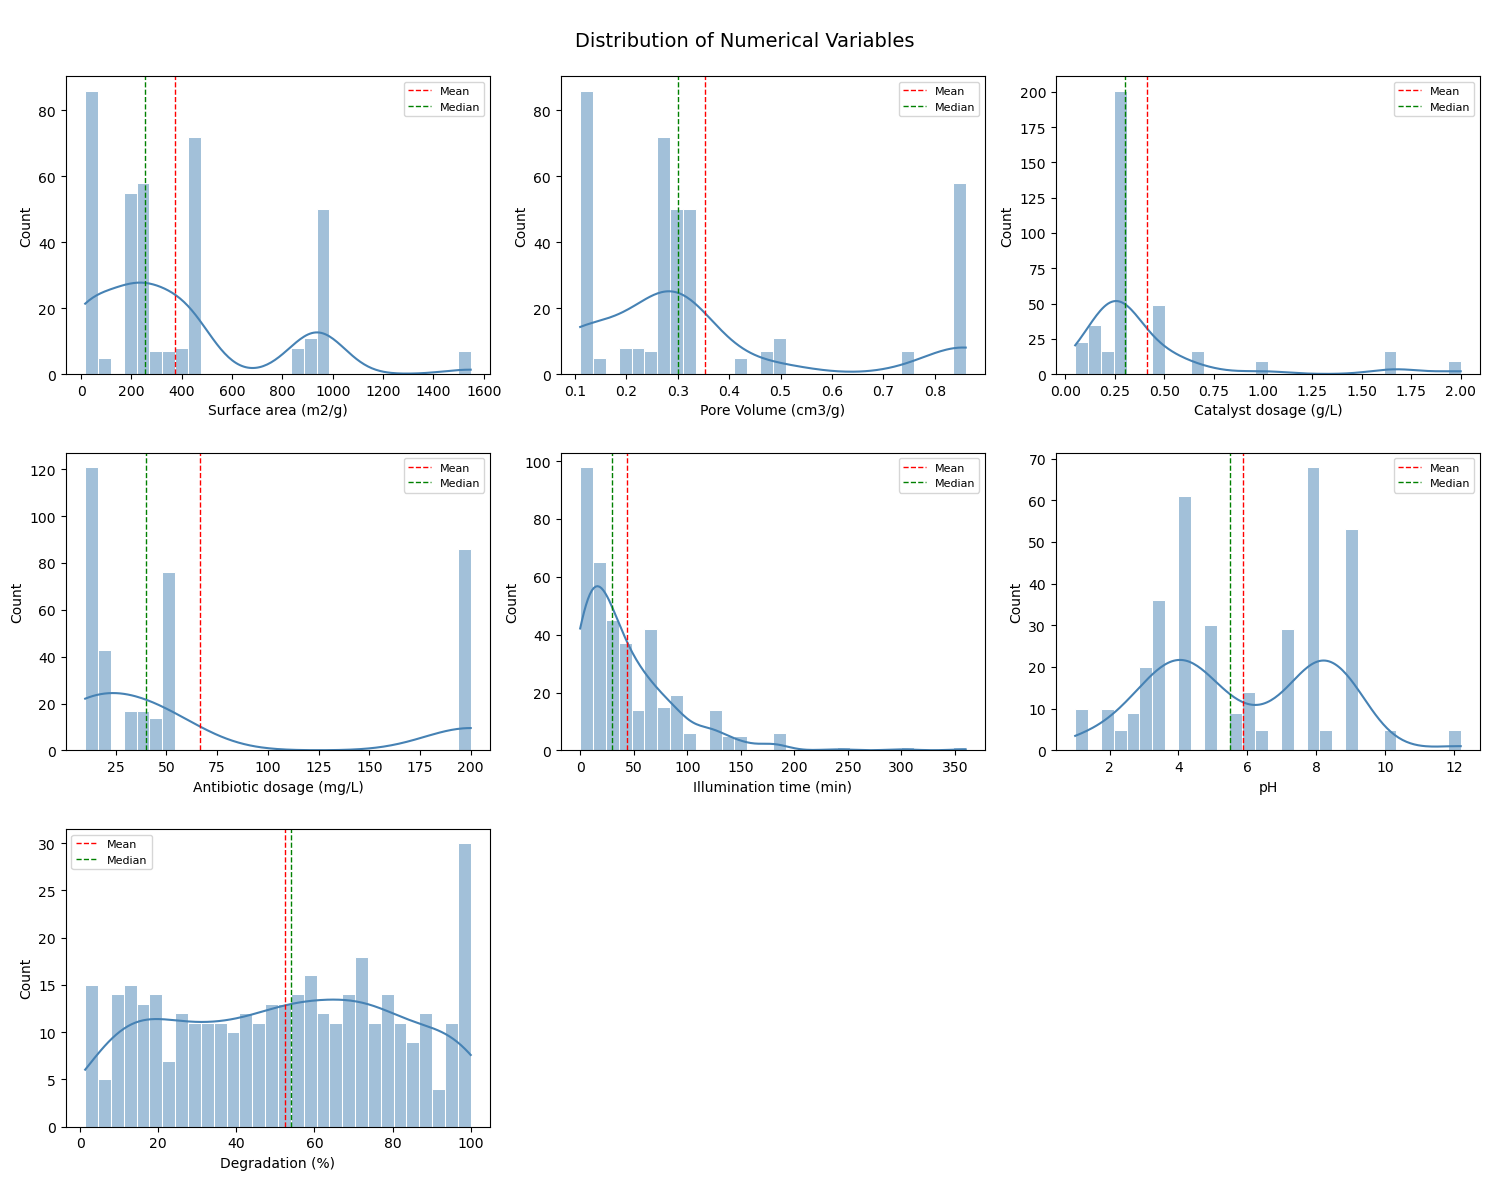

In [70]:
# UNIVARIATE EDA
NUMERIC_COLS = [
    "Surface area (m2/g)",
    "Pore Volume (cm3/g)",
    "Catalyst dosage (g/L)",
    "Antibiotic dosage (mg/L)",
    "Illumination time (min)",
    "pH",
    TARGET_COL,
]

def compute_univariate_stats(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Compute descriptive statistics (min, max, mean, median, std, IQR, skew, n_unique)."""
    rows = []
    for col in cols:
        series = pd.to_numeric(df[col], errors="coerce").dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)

        rows.append({
            "Variable": col,
            "Min": series.min(),
            "Max": series.max(),
            "Mean": series.mean(),
            "Median": series.median(),
            "Std": series.std(),
            "Q1": q1,
            "Q3": q3,
            "IQR": q3 - q1,
            "Skewness": stats.skew(series),
            "N Unique": series.nunique(),
            "N Obs": series.shape[0],
        })

    stats_df = pd.DataFrame(rows).set_index("Variable").round(3)
    return stats_df


def plot_univariate_distributions(
    df: pd.DataFrame,
    cols: list[str],
    bins: int = 30,
    ncols: int = 3,
) -> None:
    """Plot histogram + KDE for each numeric column in a grid."""
    n = len(cols)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        series = pd.to_numeric(df[col], errors="coerce").dropna()
        sns.histplot(series, bins=bins, kde=True, ax=ax, color="steelblue", edgecolor="white")
        ax.axvline(series.mean(), color="red", linestyle="--", linewidth=1, label="Mean")
        ax.axvline(series.median(), color="green", linestyle="--", linewidth=1, label="Median")
        ax.set_title(" ")
        ax.set_xlabel(col)
        ax.legend(fontsize=8)

    # Hide any unused subplots
    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle("\nDistribution of Numerical Variables", fontsize=14)
    plt.tight_layout()
    plt.show()


# Execute Phase
univariate_stats = compute_univariate_stats(df, NUMERIC_COLS)
print("UNIVARIATE DESCRIPTIVE STATISTICS")
display(univariate_stats)

# Distribution plots
plot_univariate_distributions(df, NUMERIC_COLS, bins=30, ncols=3)

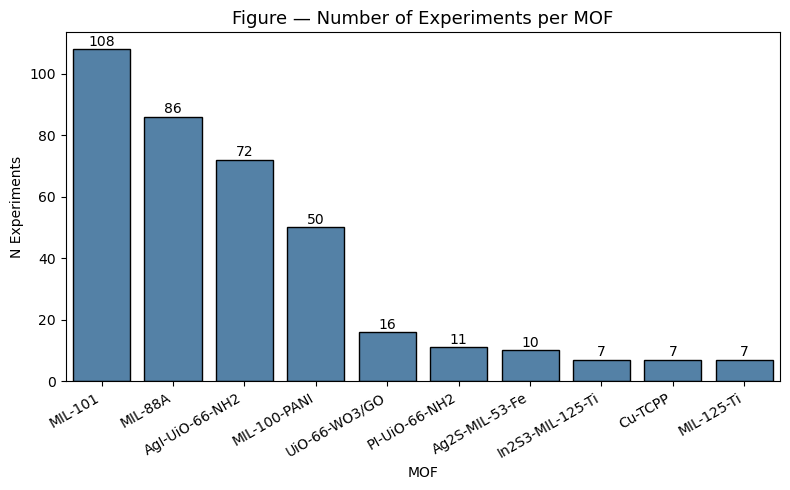

In [71]:
# Analyze MOFs (CATEGORICAL)
def plot_categorical_distribution(
    df: pd.DataFrame,
    col: str,
    order: list[str] | None = None,
    annotate: bool = True,
) -> None:
    """Bar plot of counts per category, ordered by frequency."""
    counts = df[col].value_counts()
    if order is None:
        order = counts.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        x=counts.loc[order].index,
        y=counts.loc[order].values,
        order=order,
        color="steelblue",
        edgecolor="black",
        ax=ax,
    )

    if annotate:
        for i, val in enumerate(counts.loc[order].values):
            ax.text(i, val + counts.max() * 0.01, str(val), ha="center", fontsize=10)

    ax.set_title(f"Figure — Number of Experiments per {col}", fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel("N Experiments")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Execute
plot_categorical_distribution(df, "MOF")

In [72]:
df.drop(columns=["MOF"], inplace=True)

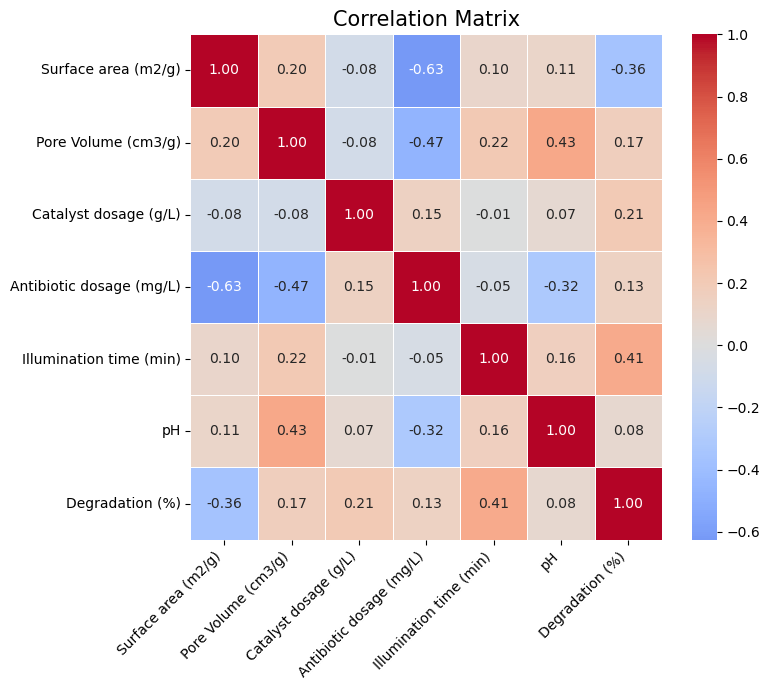

In [73]:
# CORRELATION MATRIX

corr_matrix = df.corr()

plt.figure(figsize=(8, 7))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [74]:
# VIF CHECK

# Remove target
X_vif = df.drop(columns=[TARGET_COL]).copy()

# Keep numeric variables only
X_vif = X_vif.select_dtypes(include=[np.number])

# Add intercept
X_vif_const = add_constant(X_vif)

vif_data = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

# Remove intercept from results
vif_data = vif_data[vif_data["Variable"] != "const"]

# Sort highest to lowest
vif_data = (
    vif_data
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

display(vif_data.round(3))

,Variable,VIF
0,Antibiotic dosage (mg/L),2.189
1,Surface area (m2/g),1.716
2,Pore Volume (cm3/g),1.517
3,pH,1.290
4,Illumination time (min),1.082
5,Catalyst dosage (g/L),1.041


In [75]:
X = df.drop('Degradation (%)', axis=1)
y = df['Degradation (%)']

feature_names = X.columns.tolist()
feature_names

['Surface area (m2/g)',
 'Pore Volume (cm3/g)',
 'Catalyst dosage (g/L)',
 'Antibiotic dosage (mg/L)',
 'Illumination time (min)',
 'pH']

In [76]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [ ]:
# Cross-validation configuration
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# 2. Define models
models = {
    
    "RF": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GBR": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),

    "XGBR": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        objective="reg:squarederror",
        verbosity=0
    ),
    
    "SVR": SVR(
        kernel="rbf",
        C=1.0,
        epsilon=0.1
    ),

    "AdaBoost": AdaBoostRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),

        "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1
    )
}

In [78]:
# Create preprocessing + model pipelines
pipelines = {}

for model_name, model in models.items():

    if model_name == "SVR":

        pipelines[model_name] = Pipeline([
            ("imputer", KNNImputer(n_neighbors=KNN_NEIGHBORS)),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

    else:

        pipelines[model_name] = Pipeline([
            ("imputer", KNNImputer(n_neighbors=KNN_NEIGHBORS)),
            ("model", model)
        ])

In [79]:
# Scoring metrics
scoring = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

In [80]:
# Cross-validation comparison
comparison_results = []

for model_name, pipeline in pipelines.items():

    start_time = time.time()

    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    elapsed_time = time.time() - start_time

    comparison_results.append({

        "Model": model_name,

        # Training performance
        "Train RMSE":
            -cv_results["train_RMSE"].mean(),

        # Cross-validation performance
        "CV RMSE":
            -cv_results["test_RMSE"].mean(),

        "CV RMSE Std":
            cv_results["test_RMSE"].std(),

        "CV R2":
            cv_results["test_R2"].mean(),

        "CV R2 Std":
            cv_results["test_R2"].std(),

        "CV MAE":
            -cv_results["test_MAE"].mean(),

        "Time (sec)":
            elapsed_time
    })

In [81]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Best model
comparison_df = comparison_df.sort_values(
    by="CV RMSE",
    ascending=True
).reset_index(drop=True)

print("\nMODEL COMPARISON RESULTS")
display(comparison_df.round(4))


MODEL COMPARISON RESULTS


,Model,Train RMSE,CV RMSE,CV RMSE Std,CV R2,CV R2 Std,CV MAE,Time (sec)
0,XGBR,6.2542,10.5516,1.5259,0.8655,0.0434,7.7743,1.0642
1,RF,3.7920,10.6119,2.4664,0.8603,0.0720,7.4803,0.5339
2,GBR,6.8483,11.0882,1.3040,0.8522,0.0392,8.2712,0.0641
3,LightGBM,9.1700,13.3316,1.1413,0.7880,0.0416,9.3098,12.2962
4,AdaBoost,14.8980,16.2707,0.7390,0.6879,0.0244,13.5587,0.3420
5,SVR,25.5107,26.0091,0.9728,0.2030,0.0443,22.1228,0.6166


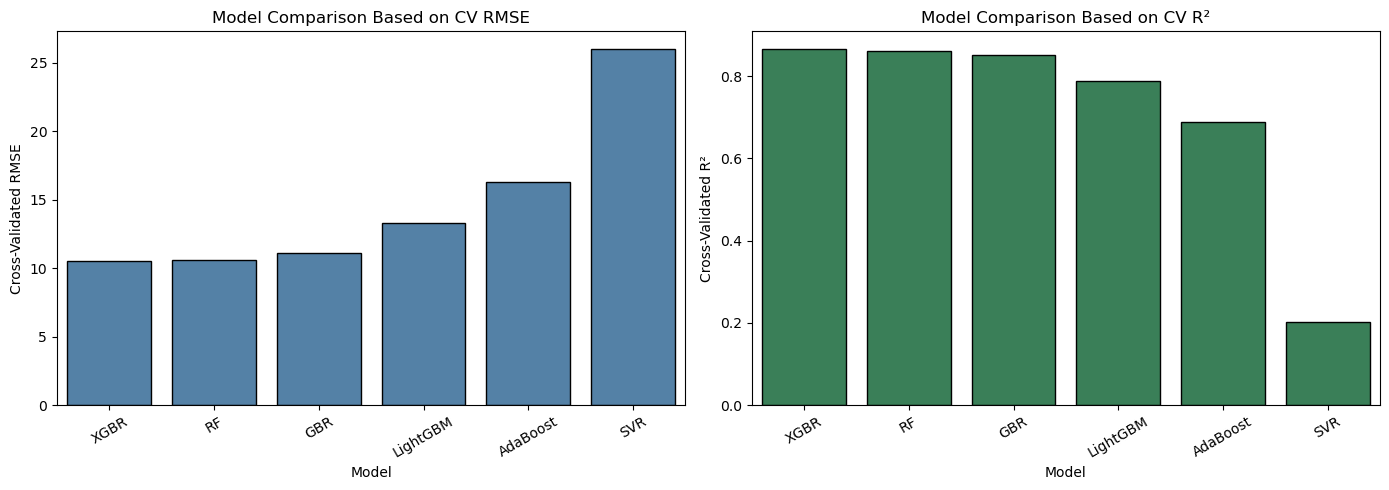

In [82]:
# MODEL COMPARISON PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
sns.barplot(
    data=comparison_df,
    x="Model",
    y="CV RMSE",
    ax=axes[0],
    color="steelblue",
    edgecolor="black"
)

axes[0].set_title("Model Comparison Based on CV RMSE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Cross-Validated RMSE")
axes[0].tick_params(axis="x", rotation=30)

# R² comparison
sns.barplot(
    data=comparison_df,
    x="Model",
    y="CV R2",
    ax=axes[1],
    color="seagreen",
    edgecolor="black"
)

axes[1].set_title("Model Comparison Based on CV R²")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Cross-Validated R²")
axes[1].tick_params(axis="x", rotation=30)


plt.tight_layout()
plt.show()

In [83]:
# Define the parameter grid for tuning
param_grid = {
    'n_estimators': [300],
    'learning_rate': [0.05, 0.07, 0.1],
    'min_samples_leaf': [1],
    # 'subsample': [0.4, 0.5, 0.6, 0.7],
    'max_depth': [3, 4, 5, 6],
}

# Set up the GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,              # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1          # Use all available CPU cores
)

# Run the grid search
grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.07, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1], 'n_estimators': [300]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [84]:
# # Define the parameter grid for tuning
# param_grid = {
#     'n_estimators': [300],
#     #'max_depth': [5, 6, 7, 8,],
# }

# # Set up the Random forest
# grid_search = GridSearchCV(
#     estimator=RandomForestRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=5,              # 5-fold cross-validation
#     scoring='r2',
#     n_jobs=-1          # Use all available CPU cores
# )

# # Run the grid search
# grid_search.fit(X_train, y_train)

In [85]:
# # Define the parameter grid for tuning
# param_grid = {
#     'n_estimators': [300],
#     'learning_rate': [0.05, 0.075, 0.1],
#     # 'max_depth': [3, 4, 5, 6, 7],
#     # 'subsample': [0.3, 0.4, 0.5, 0.6, 0.7],
#     # 'gamma': [0, 0.1],
#     # 'colsample_bytree': [0.4, 0.5, 0.7, 0.8, 1.0],
#     # 'reg_alpha': [0, 0.01, 0.1],
#     # 'reg_lambda': [1, 3, 5]
# }

# # Set up the GridSearchCV
# grid_search = GridSearchCV(
#     estimator=XGBRegressor(random_state=42),
#     param_grid=param_grid,
#     cv=5,              # 5-fold cross-validation
#     scoring='r2',
#     n_jobs=-1          # Use all available CPU cores
# )

# # Run the grid search
# grid_search.fit(X_train, y_train)

In [86]:
# Print out the best parameters and cross-validation score
print("Best hyperparameters found:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy: {:.2f}%".format(grid_search.best_score_ * 100))

best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Test set accuracy: {:.2f}%".format(test_accuracy * 100))

Best hyperparameters found:
{'learning_rate': 0.07, 'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 300}

Best cross-validation accuracy: 92.29%
Test set accuracy: 88.83%


In [87]:
# Predict & Evaluate
predictions = best_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Model Performance On Test Data: \n")
print(f"Mean Squared Error: {mse:.4f}")
print("RMSE: %f" % (rmse))
print(f"R^2 Score: {r2:.4f}")

Model Performance On Test Data: 

Mean Squared Error: 88.8348
RMSE: 9.425221
R^2 Score: 0.8883


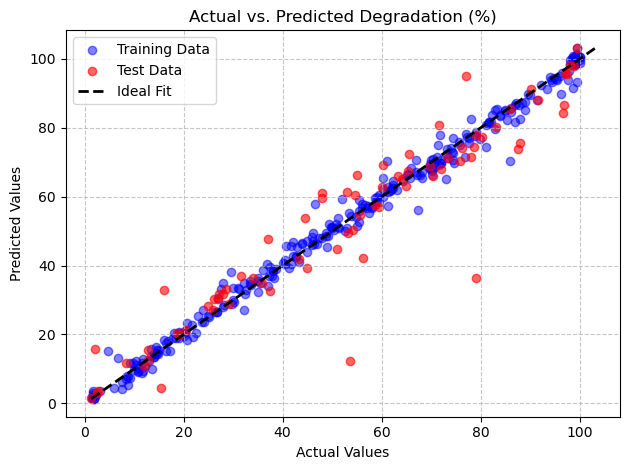

In [88]:
# Actual vs Predicted
# This shows how closely the model's predictions align with reality
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

plt.scatter(y_train, y_pred_train, alpha=0.5, color='blue', label='Training Data')
plt.scatter(y_test, y_pred_test, alpha=0.6, color='red', label='Test Data')

# Plot the ideal 1:1 line
min_val = min(y.min(), y_pred_test.min())
max_val = max(y.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal Fit')

plt.title('Actual vs. Predicted Degradation (%)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

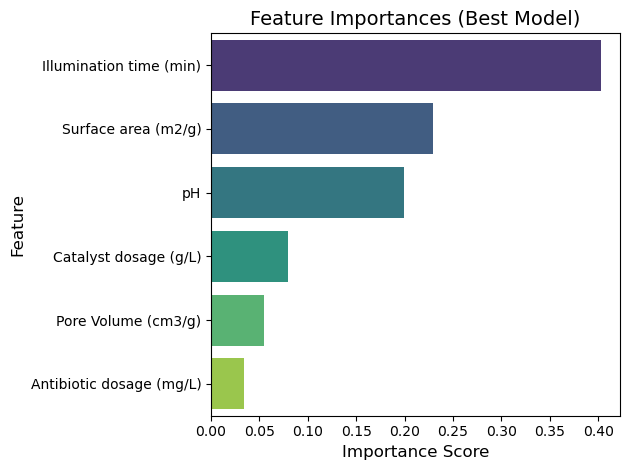

In [89]:
# Extract feature importances from the best model
importances = best_model.feature_importances_

# Create a DataFrame pairing features with their importance scores
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# # Display feature importances in text format
# print("Feature Importances:")
# print(feature_importances.to_string(index=False))

# Plot feature importances
plt.figure()
sns.barplot(
    data=feature_importances, 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title('Feature Importances (Best Model)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

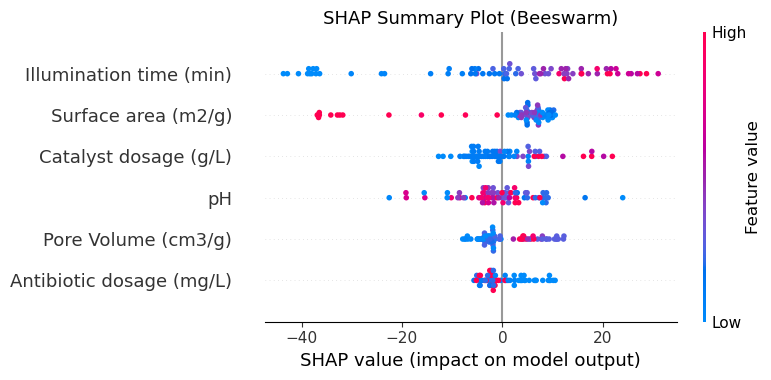

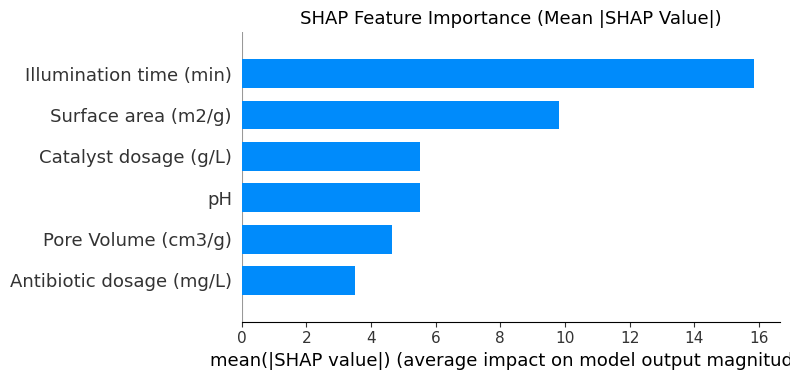

In [90]:
# SHAP Analysis

# Build the SHAP Explainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)          # Explanation object (preferred API)
shap_matrix = shap_values.values         # Raw matrix: (n_samples, n_features)

# Summary Plot (Beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot (Beeswarm)", fontsize=13)
plt.tight_layout()
plt.show()

# Feature Importance Bar Plot
plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)", fontsize=13)
plt.tight_layout()
plt.show()